# 3. EDA de la variable objetivo: reingreso antes de 30 días

Se describen `readmitted` y el objetivo binario `reingreso_30d`. La clase
positiva representa exclusivamente `<30`; `>30` y `NO` forman la clase 0.
Se cuantifican encuentros, pacientes, prevalencia, desbalance y accuracy de la
predicción mayoritaria.

In [1]:
from pathlib import Path
import re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

project_root = Path.cwd().resolve()
while not (project_root / "_config.yml").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("No se encontró _config.yml. Ejecuta el notebook dentro de la carpeta del libro.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

for _folder in ("tables", "figures"):          # se crean si no existen
    (project_root / _folder).mkdir(exist_ok=True)

from src.project_utils import *

configure_plots()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 70)
TABLES = project_root / "tables"

def md_out(text):
    display(Markdown(text))

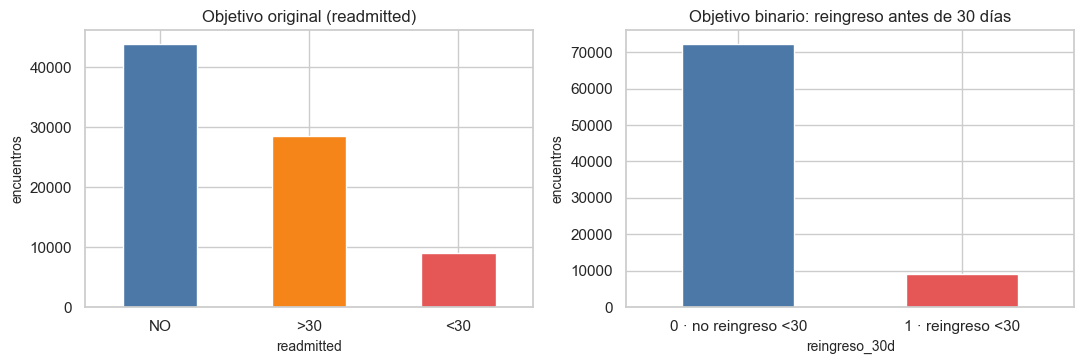

reingreso_30d,0,1,% del total
readmitted,,,
NO,43911,0,53.94
>30,28479,0,34.98
<30,0,9023,11.08


,clase,encuentros,pacientes_con_al_menos_un_encuentro_de_la_clase,%
0,sin reingreso <30 (0),72390,55413,88.92
1,reingreso <30 (1),9023,6972,11.08


In [2]:
train = load_train()
y = train[TARGET]
n, pos = len(train), int(y.sum())
neg = n - pos
mayor = max(pos, neg) / n
ratio = max(pos, neg) / min(pos, neg)
pacientes_por_clase = train.groupby(TARGET)[GROUP_COL].nunique()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
orden = [c for c in ["NO", ">30", "<30"] if c in train[RAW_TARGET].unique()]
train[RAW_TARGET].value_counts().reindex(orden).plot.bar(ax=axes[0], color=["#4c78a8", "#f58518", "#e45756"][:len(orden)], rot=0)
axes[0].set_title("Objetivo original (readmitted)"); axes[0].set_ylabel("encuentros")
y.map({0: "0 · no reingreso <30", 1: "1 · reingreso <30"}).value_counts().sort_index().plot.bar(ax=axes[1], color=["#4c78a8", "#e45756"], rot=0)
axes[1].set_title("Objetivo binario: reingreso antes de 30 días"); axes[1].set_ylabel("encuentros")
plt.tight_layout(); save_figure(fig, "03_distribucion_objetivo.png"); plt.show()

tabla = pd.crosstab(train[RAW_TARGET], y.rename("reingreso_30d")).reindex(orden)
tabla["% del total"] = (100 * tabla.sum(axis=1) / n).round(2)
display(tabla)
objetivo = pd.DataFrame({
    "clase": ["sin reingreso <30 (0)", "reingreso <30 (1)"],
    "encuentros": [neg, pos],
    "pacientes_con_al_menos_un_encuentro_de_la_clase": [pacientes_por_clase.get(0, 0), pacientes_por_clase.get(1, 0)],
    "%": [100 * neg / n, 100 * pos / n],
}).round(2)
objetivo.to_csv(TABLES / "objetivo_distribucion.csv", index=False)
display(objetivo)

In [3]:
md_out(f"- **Clase positiva `<30`:** {es(pos, 0)} encuentros ({es(pos / n, 1, pct=True)}).\n"
       f"- **Clase 0 (`>30` o `NO`):** {es(neg, 0)} encuentros ({es(neg / n, 1, pct=True)}).\n"
       f"- **Desbalance:** {es(ratio, 2)} : 1; la clase minoritaria tiene {es(min(pos, neg), 0)} encuentros.\n"
       f"- **Accuracy de predecir siempre la clase mayoritaria:** {es(mayor, 1, pct=True)}.\n\n"
       "Este accuracy alto no implica utilidad: el modelo mayoritario tiene recall 0 para `<30`. Por ello se priorizan recall, precision, F1, ROC-AUC, Average Precision, curva PR y matriz de confusión, siempre con `<30` como clase positiva.")

- **Clase positiva `<30`:** 9.023 encuentros (11,1 %).
- **Clase 0 (`>30` o `NO`):** 72.390 encuentros (88,9 %).
- **Desbalance:** 8,02 : 1; la clase minoritaria tiene 9.023 encuentros.
- **Accuracy de predecir siempre la clase mayoritaria:** 88,9 %.

Este accuracy alto no implica utilidad: el modelo mayoritario tiene recall 0 para `<30`. Por ello se priorizan recall, precision, F1, ROC-AUC, Average Precision, curva PR y matriz de confusión, siempre con `<30` como clase positiva.

## Validación cruzada: casos de la clase minoritaria por pliegue

La validación cruzada usa `StratifiedGroupKFold` con 5 pliegues (los **mismos pliegues** se reutilizan en los capítulos 5, 8 y 9): estratificada (misma proporción de clases) y agrupada por paciente
(un paciente nunca queda en dos pliegues). Se comprueba que cada pliegue tenga suficientes casos de cada clase.

In [4]:
filas = []
for k, (tr, va) in enumerate(cv_folds(y, train[GROUP_COL]), start=1):
    filas.append({"pliegue": k, "encuentros_validación": len(va), "pacientes_validación": train.iloc[va][GROUP_COL].nunique(),
                  "reingresos_validación": int(y.iloc[va].sum()), "reingreso_%": 100 * y.iloc[va].mean(),
                  "pacientes_compartidos_con_entrenamiento": len(set(train.iloc[tr][GROUP_COL]) & set(train.iloc[va][GROUP_COL]))})
folds = pd.DataFrame(filas)
display(folds.round(2))
md_out(f"Cada pliegue tiene entre {es(folds['reingresos_validación'].min(), 0)} y {es(folds['reingresos_validación'].max(), 0)} casos positivos y "
       f"ningún paciente compartido con su entrenamiento ({int(folds['pacientes_compartidos_con_entrenamiento'].sum())} en total): "
       "la validación es estable y no hay contaminación por paciente.")

,pliegue,encuentros_validación,pacientes_validación,reingresos_validación,reingreso_%,pacientes_compartidos_con_entrenamiento
0,1,16362,11441,1850,11.31,0
1,2,16374,11470,1839,11.23,0
2,3,16277,11414,1820,11.18,0
3,4,16062,11430,1760,10.96,0
4,5,16338,11476,1754,10.74,0


Cada pliegue tiene entre 1.754 y 1.850 casos positivos y ningún paciente compartido con su entrenamiento (0 en total): la validación es estable y no hay contaminación por paciente.

## Coherencia con el objetivo original

`readmitted` se conserva únicamente para describir sus tres categorías y para
construir `reingreso_30d`. No entra como predictora. La definición `<30` frente
a `>30`/`NO` coincide con la formulación de reingreso temprano del artículo
original y permanece fija en todo el libro.